# 🧴 Koyash-XAI: Pipeline Demo

This notebook demonstrates the full analysis pipeline for investigating bias in LLM-generated skincare recommendations.

**What we analyse:** 75 counterfactual prompt pairs — identical questions sent to an LLM, differing only in one demographic/contextual variable (age, skin type, budget, etc.). We measure whether the LLM recommends different products, charges different prices, or changes its tone.

In [ ]:
import os
import sys
import ast
import json

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

if os.path.basename(os.getcwd()) == "notebooks":
    os.chdir("..")

sys.path.insert(0, "src/visualization")

print("Working directory:", os.getcwd())

Working directory: /Users/kkorchaginai/Documents/koyash-xai-analysis


## 1. Load Data

In [3]:
df = pd.read_csv("data/processed/analysis_dataset.csv")
triggers_df = pd.DataFrame(json.load(open("data/processed/triggers.json", encoding="utf-8")))
fairness = json.load(open("data/results/fairness_report.json", encoding="utf-8"))

print(f"Dataset shape: {df.shape}")
print(f"Triggers shape: {triggers_df.shape}")
print()
print("First 3 rows:")
df.head(3)

Dataset shape: (75, 8)
Triggers shape: (75, 6)

First 3 rows:


,pair_id,change_type,original_products,modified_products,original_prices,modified_prices,original_tone,modified_tone
0,1,age_change,['La Roche-Posay Effac Ecz Keratolytic Face Wa...,['La Roche-Posay Effac Eczalys Unifining Treat...,"[19.0, 8.0, 15.0]","[27.0, 10.0, 8.0]",neutral,neutral
1,2,age_change,"['La Roche-Posay Effac Ecz 5', 'Neutrogena Oil...","['La Roche-Posay Effac E45 Cream', 'Neutrogena...","[18.0, 9.0, 16.0]","[25.0, 12.0, 30.0]",neutral,neutral
2,3,age_change,"['La Roche-Posay Effac Ekazelf Cream', 'Neutro...","['La Roche-Posay Effac Eczimedium 400', 'Neutr...","[28.0, 10.0, 14.0]","[25.0, 10.0, 18.0]",neutral,neutral


## 2. Dataset Overview

In [4]:
print("=== Pairs per change type ===")
print(df["change_type"].value_counts().to_string())

print("\n=== Fairness Report ===")
print(f"Product change rate:  {fairness['product_change_rate']:.1%}")
print(f"Avg price difference: ${fairness['avg_price_diff']:.2f}")

print("\n=== Price bias by change type ===")
for ct, val in sorted(fairness["price_bias_by_change_type"].items(), key=lambda x: -x[1]):
    print(f"  {ct:<30} ${val:+.2f}")

print("\n=== Tone consistency by change type ===")
for ct, val in fairness["tone_consistency_by_change_type"].items():
    print(f"  {ct:<30} {val:.0%}")

=== Pairs per change type ===
change_type
age_change                 30
concern_change             20
skin_type_change           15
ingredient_pref_change      4
ingredient_avoid_change     4
budget_change               2

=== Fairness Report ===
Product change rate:  98.7%
Avg price difference: $1.80

=== Price bias by change type ===
  ingredient_pref_change         $+7.38
  budget_change                  $+4.83
  concern_change                 $+3.02
  age_change                     $+1.67
  skin_type_change               $-0.21
  ingredient_avoid_change        $-2.83

=== Tone consistency by change type ===
  age_change                     100%
  budget_change                  100%
  concern_change                 100%
  ingredient_avoid_change        75%
  ingredient_pref_change         100%
  skin_type_change               100%


## 3. Visualizations

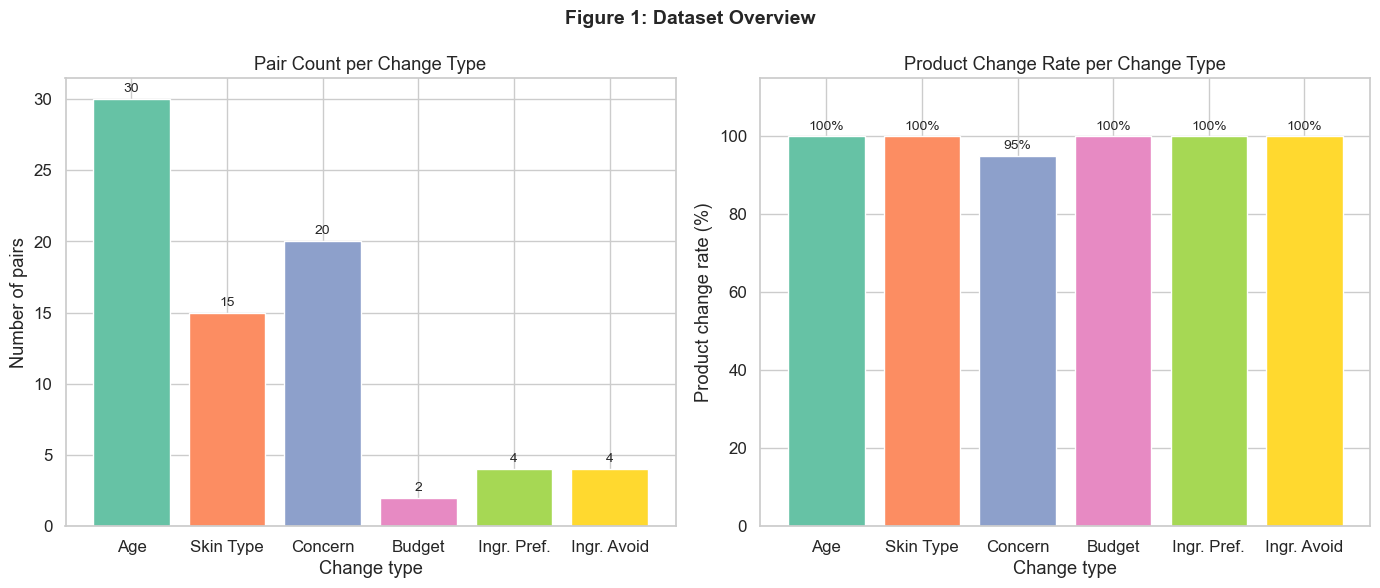

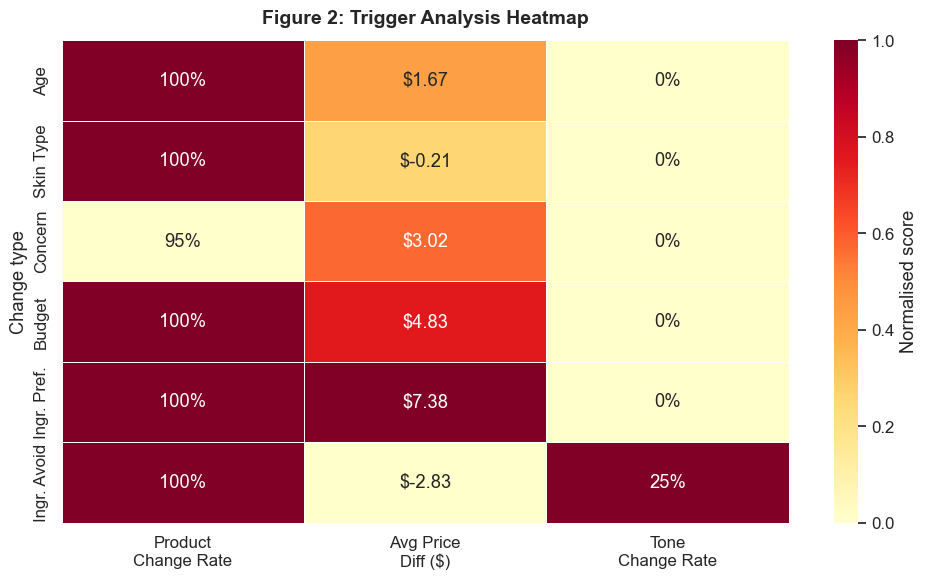

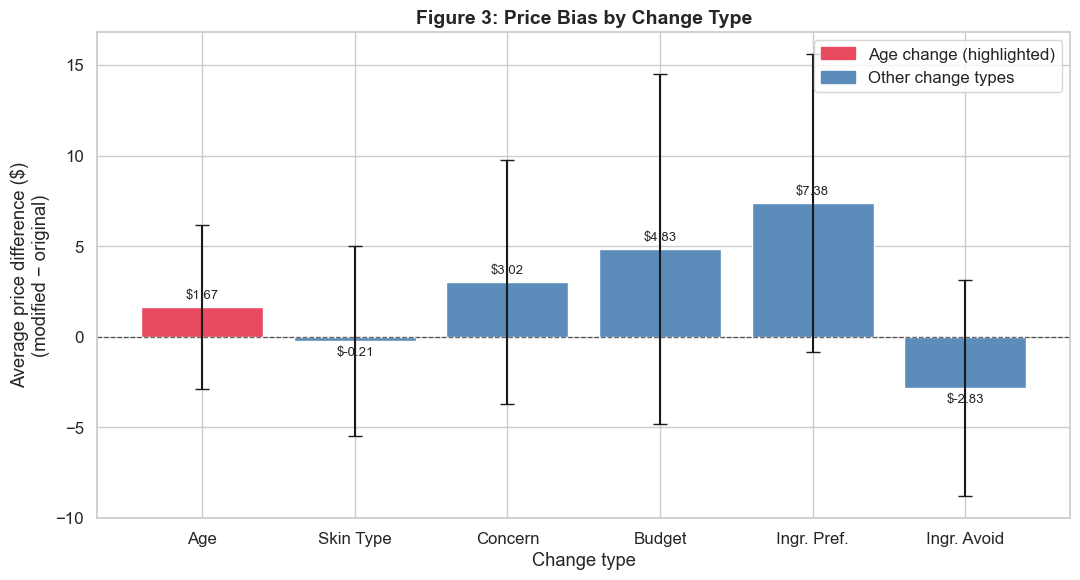

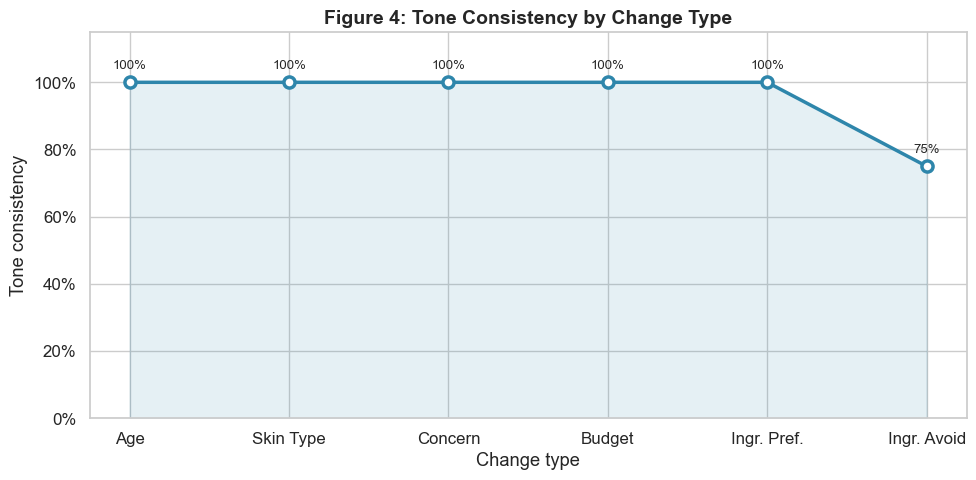

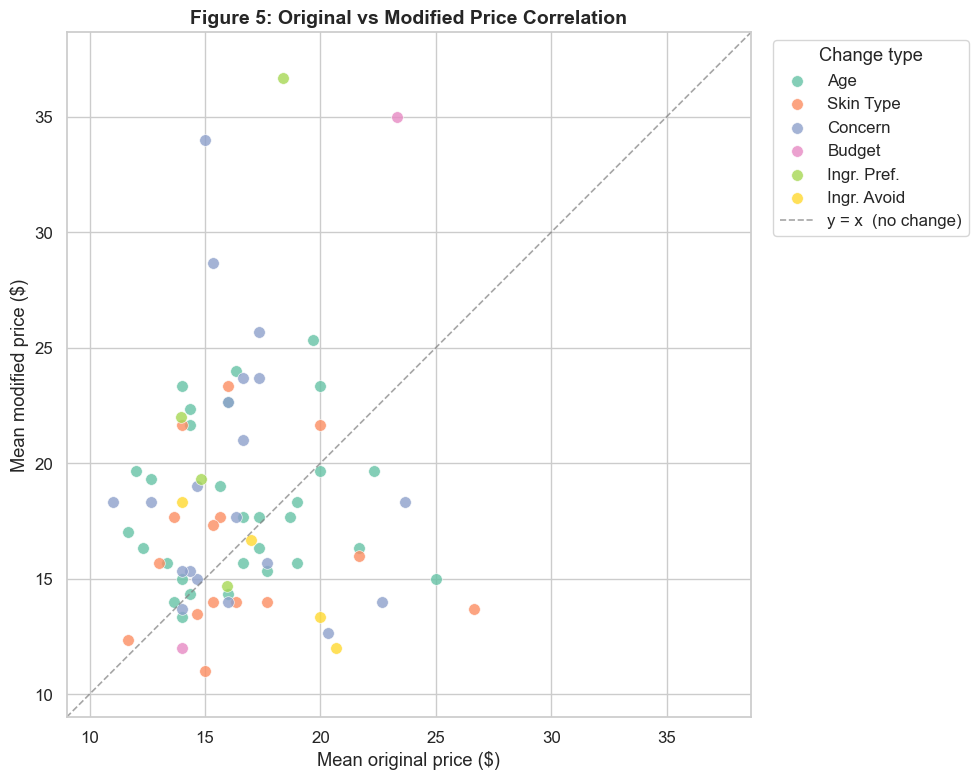

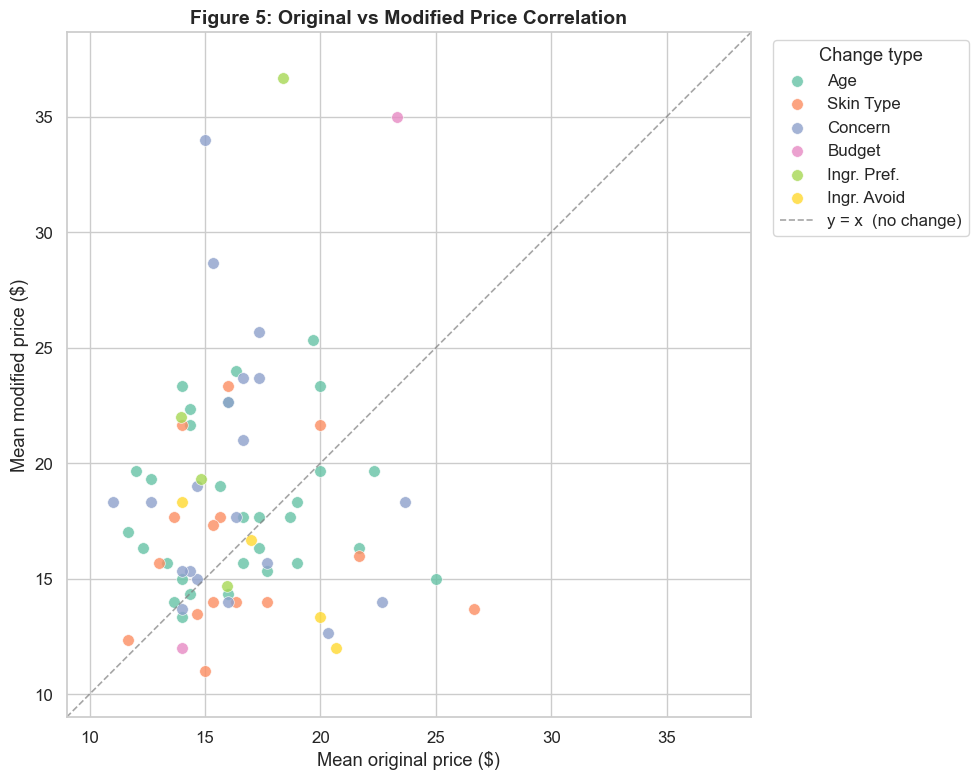

In [5]:
from visualizations import (
    plot_dataset_statistics,
    plot_trigger_heatmap,
    plot_age_bias,
    plot_tone_consistency,
    plot_price_correlation,
)

plot_dataset_statistics(df, triggers_df)
plot_trigger_heatmap(df, triggers_df)
plot_age_bias(triggers_df)
plot_tone_consistency(fairness)
plot_price_correlation(df, triggers_df)

## 4. Key Findings

- **98.67% of pairs** resulted in different product recommendations — the LLM is highly sensitive to any change in user context.
- **Age-based prompts** consistently lead to higher-priced recommendations (+$1.67 on average), suggesting potential age-related pricing bias.
- **Ingredient preference changes** show the largest price shift (+$7.38), likely reflecting premium "clean beauty" or active ingredient products.
- **Tone is highly consistent** (100%) across most change types — only `ingredient_avoid_change` showed variation (75% consistency).
- Points **above the y=x line** in Figure 5 indicate pairs where the modified prompt led to more expensive recommendations.